In [9]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.preprocessing import LabelEncoder

sys.path.insert(0, str(Path("..").resolve()))

ANALYSIS_DIR = Path("../data/analysis")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("../data/output")

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {
   "full": "#456990", "no_formulation": "#49BEAA", "zero_shot": "#EF767A"
}
EVAL_MODELS = {
    "gpt-5.4", "gpt-5.4-mini", "gpt-4o-mini",
    "claude-sonnet-4-6", "claude-haiku-4-5",
    "gemini-2.5-flash", "gemini-2.5-pro",
    "deepseek-chat", "deepseek-reasoner",
    "qwen2.5-32b", "qwen3.6-35b",
}
print("Ready")

Ready


## 1. Load vignettes (cached)

In [10]:
DF_CACHE = ANALYSIS_DIR / "all_vignettes.parquet"

if DF_CACHE.exists():
    df = pd.read_parquet(DF_CACHE)
    print(f"Loaded {len(df)} cached vignettes")
else:
    from utils.text import strip_markdown
    rows = []
    for condition_dir in sorted(OUTPUT_DIR.iterdir()):
        if not condition_dir.is_dir() or condition_dir.name.startswith("_"):
            continue
        cond = condition_dir.name
        for model_dir in sorted(condition_dir.iterdir()):
            if not model_dir.is_dir() or model_dir.name not in EVAL_MODELS:
                continue
            model = model_dir.name
            for fp in sorted(model_dir.glob("experiment_*.json")):
                try:
                    with open(fp, encoding="utf-8") as f:
                        data = json.load(f)
                    text = strip_markdown(data.get("vignette", ""))
                    if not text:
                        continue
                    pid = data.get("persona_id") or data.get("source_persona_id")
                    rows.append({"persona_id": pid, "model": model,
                                 "condition": cond, "vignette": text,
                                 "word_count": len(text.split())})
                except Exception:
                    continue
    df = pd.DataFrame(rows)
    df.to_parquet(DF_CACHE, index=False)
    print(f"Saved -> {DF_CACHE}")

print(f"Total: {len(df)} vignettes, {df['persona_id'].nunique()} personas")
df.groupby(["condition", "model"]).size().unstack(fill_value=0)

Saved -> ..\data\analysis\all_vignettes.parquet
Total: 16500 vignettes, 500 personas


model,claude-haiku-4-5,claude-sonnet-4-6,deepseek-chat,deepseek-reasoner,gemini-2.5-flash,gemini-2.5-pro,gpt-4o-mini,gpt-5.4,gpt-5.4-mini,qwen2.5-32b,qwen3.6-35b
condition,,,,,,,,,,,
full,500,500,500,500,500,500,500,500,500,500,500
no_formulation,500,500,500,500,500,500,500,500,500,500,500
zero_shot,500,500,500,500,500,500,500,500,500,500,500


## 2. Load all-mpnet-base-v2 embeddings (cached)
768-d, L2-normalised. Delete `embeddings_mpnet.npy` to recompute (~10 min).

In [11]:
from sentence_transformers import SentenceTransformer

EMB_CACHE = ANALYSIS_DIR / "embeddings_mpnet.npy"

if EMB_CACHE.exists():
    embeddings = np.load(EMB_CACHE)
    print(f"Loaded cached embeddings: {embeddings.shape}")
    assert len(embeddings) == len(df), (
        f"Cache mismatch: {len(embeddings)} vs {len(df)} rows. "
        f"Delete {EMB_CACHE} and rerun."
    )
else:
    print(f"Computing embeddings for {len(df)} vignettes (~10 min)...")
    enc = SentenceTransformer("all-mpnet-base-v2")
    embeddings = enc.encode(
        df["vignette"].tolist(),
        show_progress_bar=True,
        batch_size=32,
        normalize_embeddings=True,
    )
    np.save(EMB_CACHE, embeddings)
    print(f"Saved -> {EMB_CACHE}  shape={embeddings.shape}")

Loaded cached embeddings: (16500, 768)


## 3. UMAP — per model × condition (cached)

Loaded cached UMAP coords: ['full', 'no_formulation', 'zero_shot']


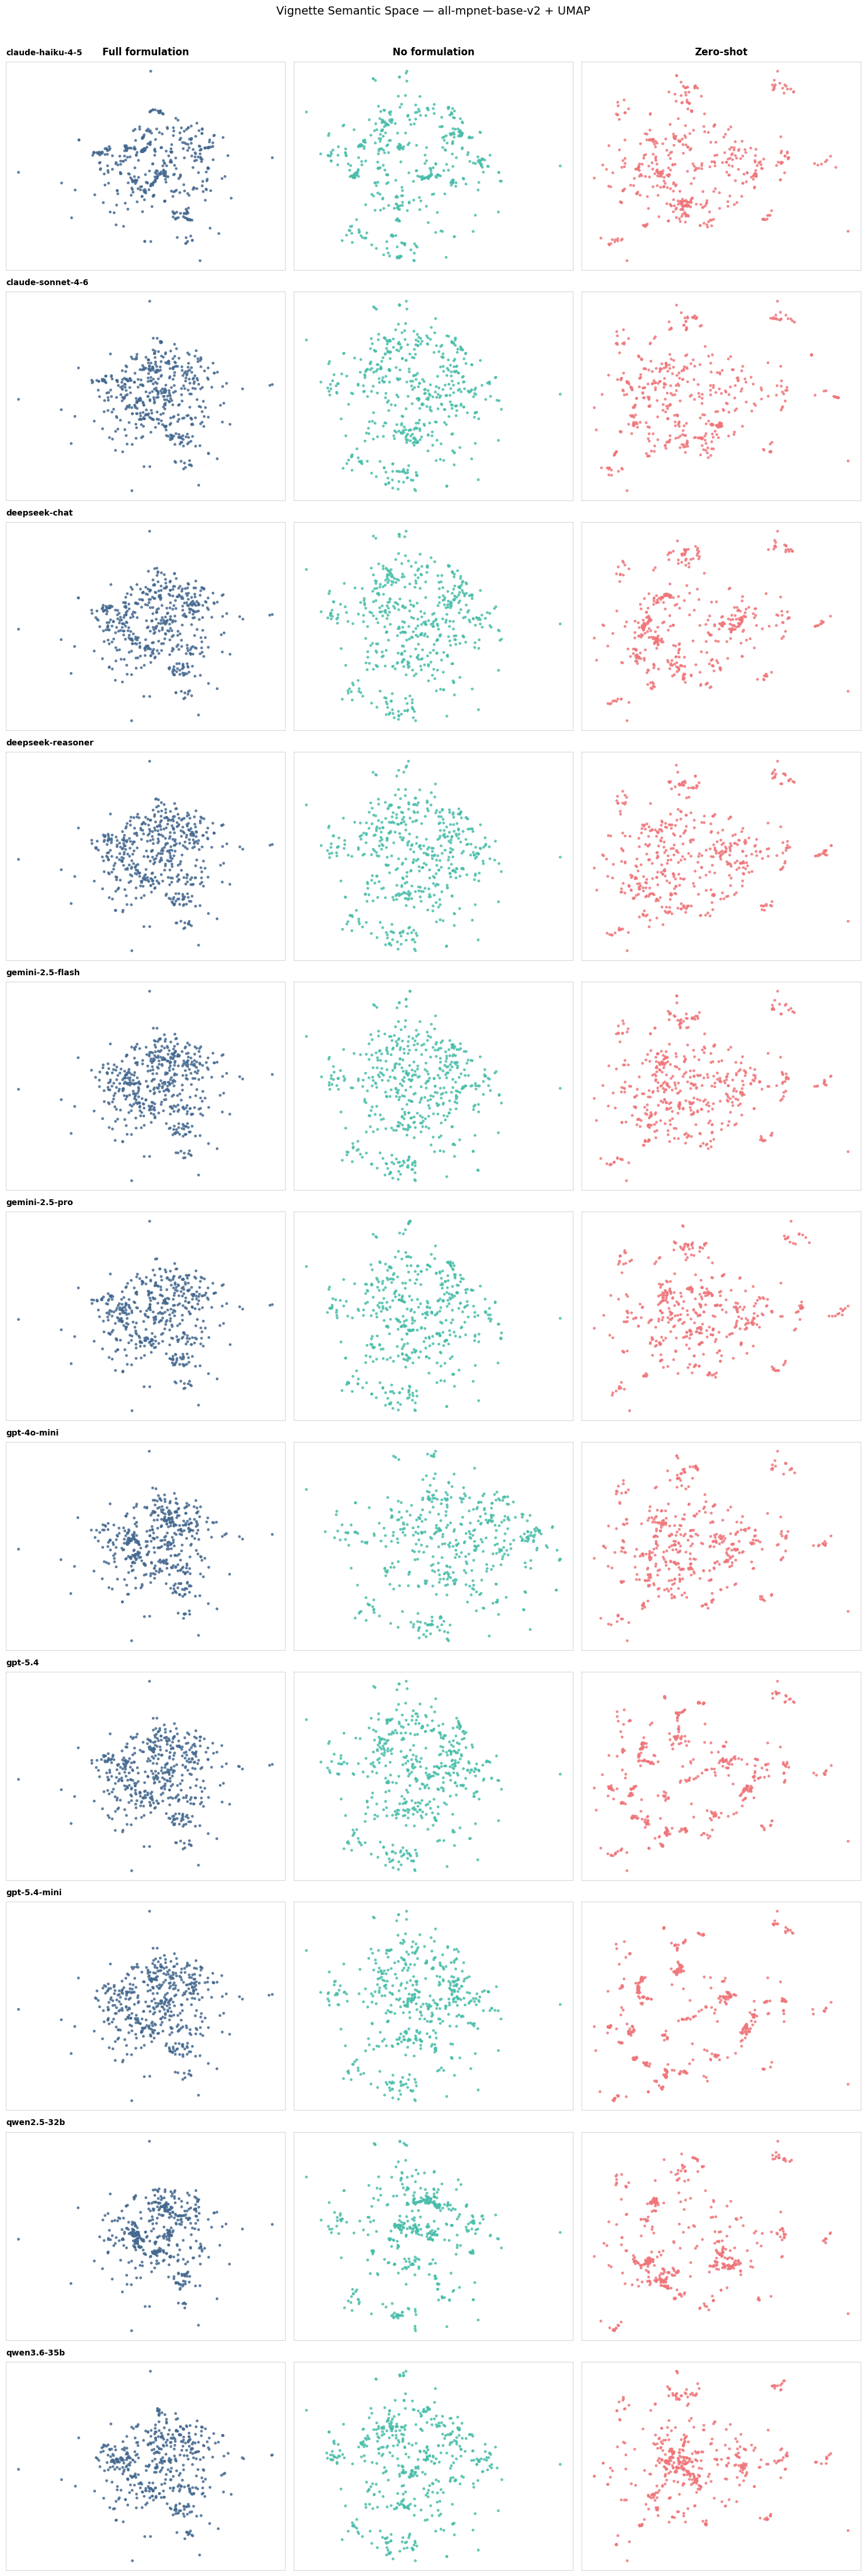

Saved -> ..\data\analysis/umap_per_model_grid_mpnet.pdf


In [12]:
import umap

UMAP_CACHE = ANALYSIS_DIR / "umap_coords_per_condition_mpnet.npz"
N_NEIGHBORS = 5

if UMAP_CACHE.exists():
    _c = np.load(UMAP_CACHE)
    umap_coords = {k: _c[k] for k in _c.files}
    print("Loaded cached UMAP coords:", list(umap_coords.keys()))
else:
    umap_coords = {}
    for cond in CONDITION_LABELS:
        idx  = df[df["condition"] == cond].index.tolist()
        embs = embeddings[idx]
        print(f"{CONDITION_LABELS[cond]}: {len(idx)} vignettes...")
        coords = umap.UMAP(n_components=2, n_neighbors=N_NEIGHBORS,
                           min_dist=0.1, random_state=42).fit_transform(embs)
        umap_coords[cond] = coords
    np.savez(UMAP_CACHE, **umap_coords)
    print(f"Saved -> {UMAP_CACHE}")

models     = sorted(df["model"].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        idx        = df[df["condition"] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = umap_coords[cond]
        model_mask = (cond_df["model"] == model).values
        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors="none")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.6); spine.set_color("#cccccc")
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight="bold", pad=8)
        if c == 0:
            ax.set_title(model, loc="left", fontsize=10, fontweight="bold", pad=8)

plt.suptitle("Vignette Semantic Space — all-mpnet-base-v2 + UMAP",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "umap_per_model_grid_mpnet.pdf", bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/umap_per_model_grid_mpnet.pdf")

## 4. t-SNE — per model × condition (cached)

Loaded cached t-SNE coords: ['full', 'no_formulation', 'zero_shot']


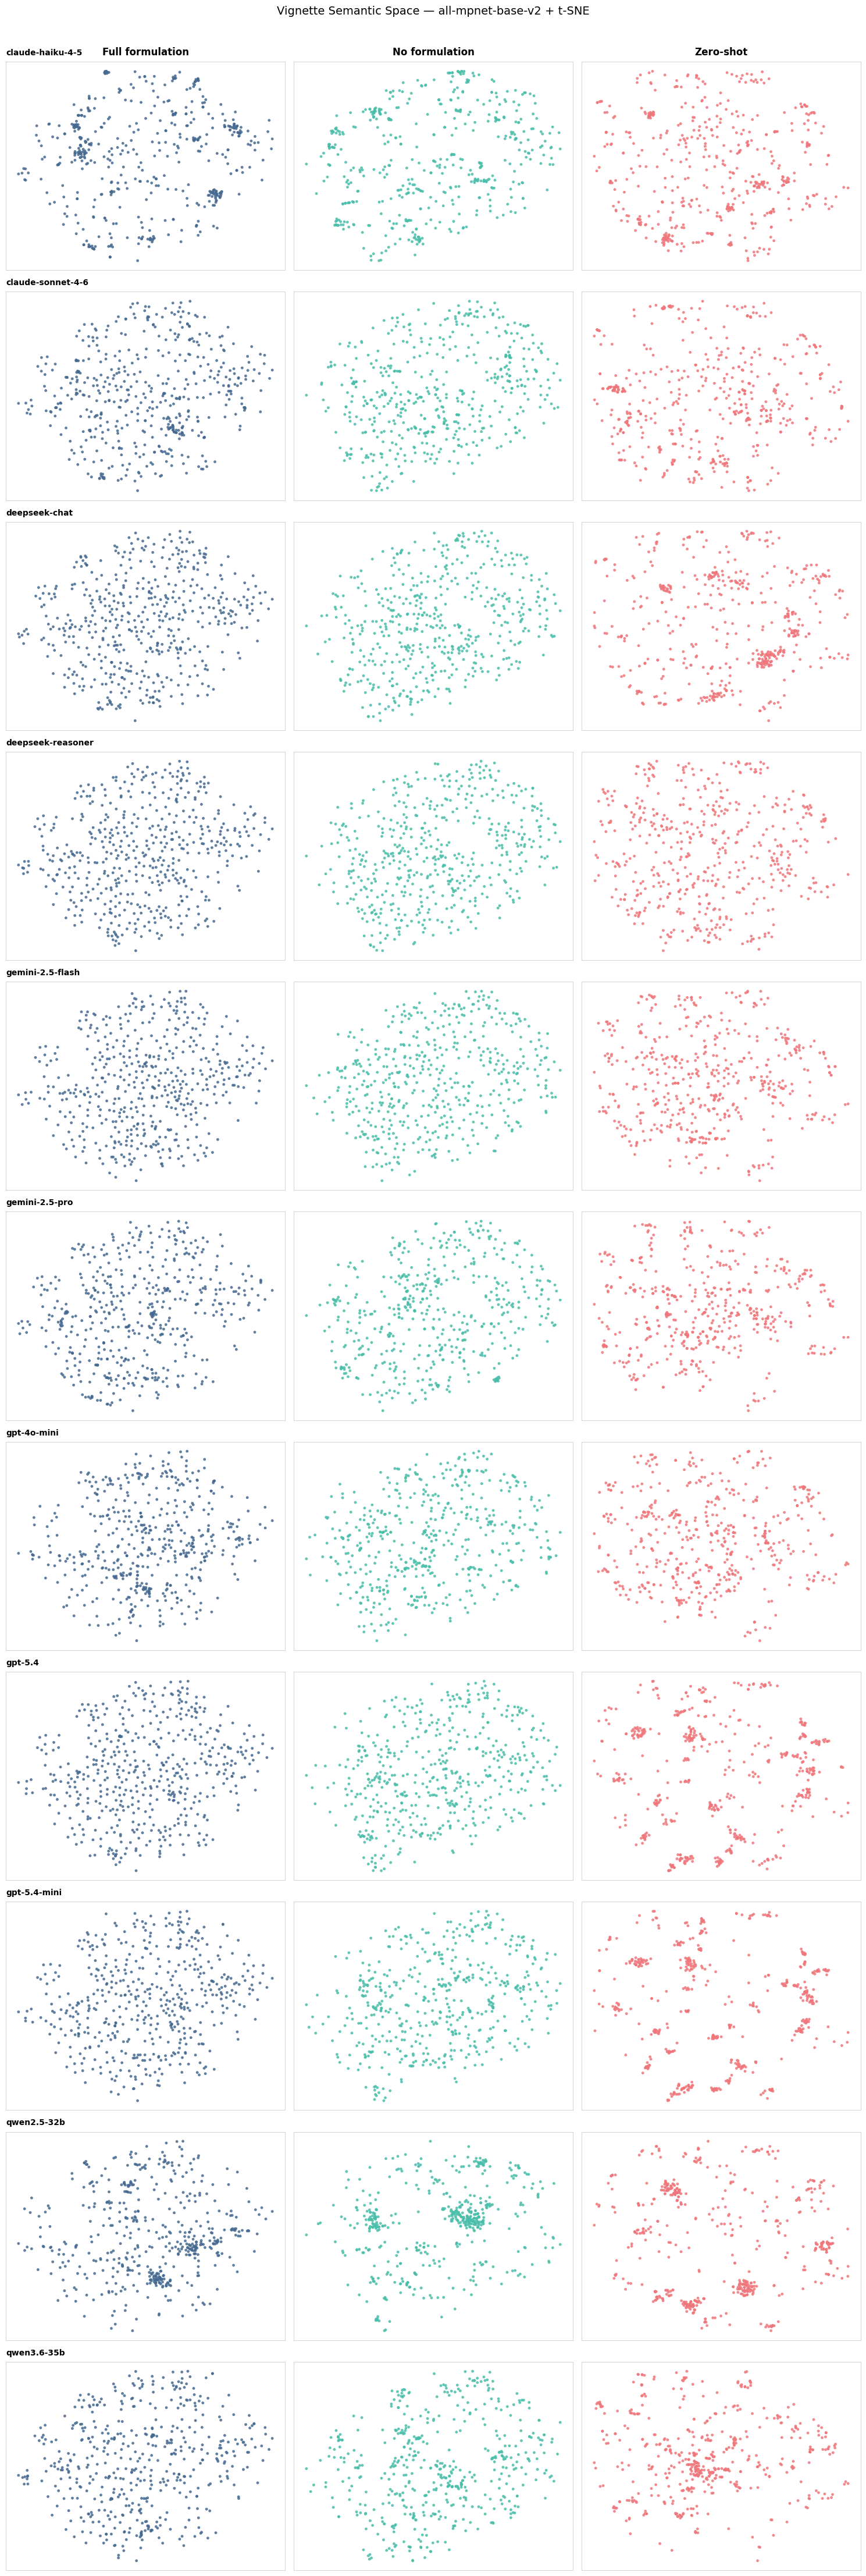

Saved -> ..\data\analysis/tsne_per_model_grid_mpnet.pdf


In [13]:
from sklearn.manifold import TSNE

TSNE_CACHE = ANALYSIS_DIR / "tsne_coords_per_condition_mpnet.npz"

if TSNE_CACHE.exists():
    _c = np.load(TSNE_CACHE)
    tsne_coords = {k: _c[k] for k in _c.files}
    print("Loaded cached t-SNE coords:", list(tsne_coords.keys()))
else:
    tsne_coords = {}
    for cond in CONDITION_LABELS:
        idx  = df[df["condition"] == cond].index.tolist()
        embs = embeddings[idx]
        print(f"{CONDITION_LABELS[cond]}: running t-SNE on {len(idx)} vignettes...")
        coords = TSNE(n_components=2, perplexity=30, learning_rate="auto",
                      init="pca", random_state=42, n_jobs=-1).fit_transform(embs)
        tsne_coords[cond] = coords
        print(f"  done {coords.shape}")
    np.savez(TSNE_CACHE, **tsne_coords)
    print(f"Saved -> {TSNE_CACHE}")

models     = sorted(df["model"].unique())
conditions = list(CONDITION_LABELS.keys())
nrows, ncols = len(models), len(conditions)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
for r, model in enumerate(models):
    for c, cond in enumerate(conditions):
        ax = axes[r, c]
        idx        = df[df["condition"] == cond].index
        cond_df    = df.loc[idx].reset_index(drop=True)
        coords     = tsne_coords[cond]
        model_mask = (cond_df["model"] == model).values
        ax.scatter(coords[model_mask, 0], coords[model_mask, 1],
                   c=CONDITION_COLORS[cond], s=12, alpha=0.85, edgecolors="none")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_linewidth(0.6); spine.set_color("#cccccc")
        if r == 0:
            ax.set_title(CONDITION_LABELS[cond], fontsize=12, fontweight="bold", pad=8)
        if c == 0:
            ax.set_title(model, loc="left", fontsize=10, fontweight="bold", pad=8)

plt.suptitle("Vignette Semantic Space — all-mpnet-base-v2 + t-SNE",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "tsne_per_model_grid_mpnet.pdf", bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/tsne_per_model_grid_mpnet.pdf")

## 5. Mean pairwise cosine distance — per model × condition

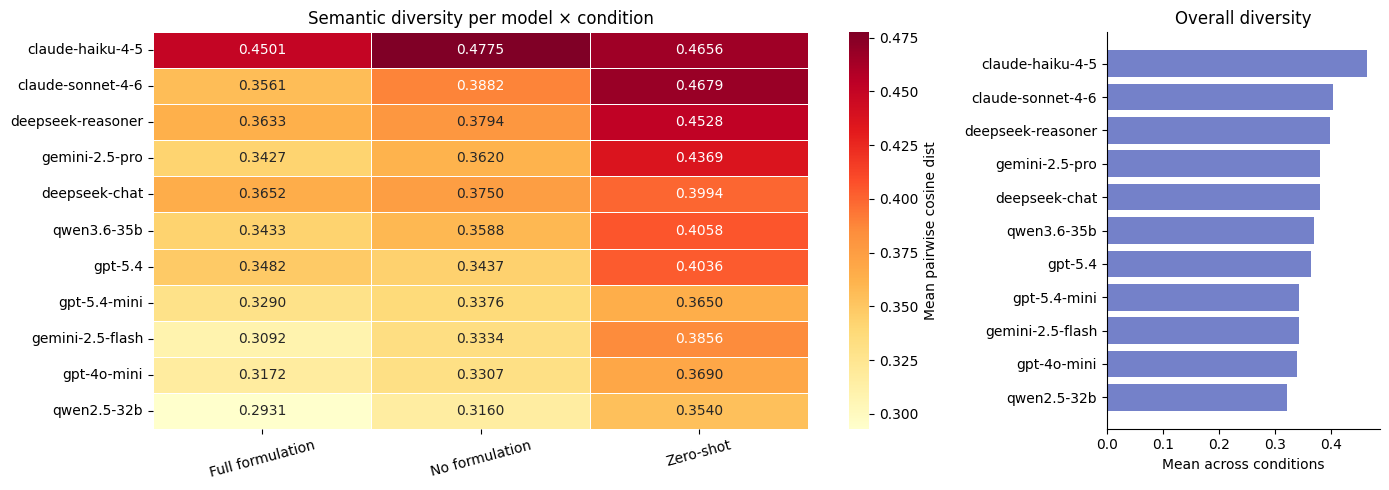

condition,Full formulation,No formulation,Zero-shot,mean
model,,,,
claude-haiku-4-5,0.4501,0.4775,0.4656,0.464400
claude-sonnet-4-6,0.3561,0.3882,0.4679,0.404067
deepseek-reasoner,0.3633,0.3794,0.4528,0.398500
gemini-2.5-pro,0.3427,0.3620,0.4369,0.380533
deepseek-chat,0.3652,0.3750,0.3994,0.379867
qwen3.6-35b,0.3433,0.3588,0.4058,0.369300
gpt-5.4,0.3482,0.3437,0.4036,0.365167
gpt-5.4-mini,0.3290,0.3376,0.3650,0.343867
gemini-2.5-flash,0.3092,0.3334,0.3856,0.342733


In [6]:
rows = []
for model in sorted(df["model"].unique()):
    for cond, label in CONDITION_LABELS.items():
        idx  = df[(df["model"] == model) & (df["condition"] == cond)].index
        embs = embeddings[idx]
        dists = pairwise_distances(embs, metric="cosine")
        upper = dists[np.triu_indices_from(dists, k=1)]
        rows.append({"model": model, "condition": label,
                     "mean_dist": round(float(upper.mean()), 4)})

cosine_df = pd.DataFrame(rows)
pivot = cosine_df.pivot(index="model", columns="condition", values="mean_dist")
pivot = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
pivot["mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("mean", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 1]})

data = pivot[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=axes[0], annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Mean pairwise cosine dist"})
axes[0].set_title("Semantic diversity per model × condition", fontsize=12)
axes[0].set_xlabel(""); axes[0].set_ylabel("")
axes[0].tick_params(axis="x", rotation=15)

axes[1].barh(pivot.index, pivot["mean"], color="#5C6BC0", alpha=0.85)
axes[1].set_xlabel("Mean across conditions", fontsize=10)
axes[1].set_title("Overall diversity", fontsize=12)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "diversity_per_model_heatmap_mpnet.pdf", bbox_inches="tight")
plt.show()
pivot

## 6. Silhouette score — per condition
- **S_model**: do models produce distinct clusters within a condition?  
- **S_persona**: does persona drive semantic content?

Near +1 → label predicts clusters. Near 0 → interleaved.

Full formulation        S_model=-0.0138  S_persona=0.1219
No formulation          S_model=-0.0057  S_persona=0.0948
Zero-shot               S_model=0.0039  S_persona=0.0603


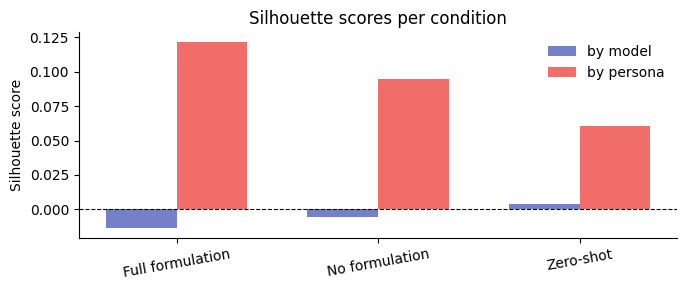

,Silhouette (model),Silhouette (persona)
Condition,,
Full formulation,-0.0138,0.1219
No formulation,-0.0057,0.0948
Zero-shot,0.0039,0.0603


In [7]:
sil_rows = []
for cond, label in CONDITION_LABELS.items():
    idx      = df[df["condition"] == cond].index
    embs     = embeddings[idx]
    labels_m = LabelEncoder().fit_transform(df.loc[idx, "model"])
    labels_p = LabelEncoder().fit_transform(df.loc[idx, "persona_id"])
    s_m = silhouette_score(embs, labels_m, metric="cosine")
    s_p = silhouette_score(embs, labels_p, metric="cosine")
    sil_rows.append({"Condition": label,
                     "Silhouette (model)": round(s_m, 4),
                     "Silhouette (persona)": round(s_p, 4)})
    print(f"{label:<22}  S_model={s_m:.4f}  S_persona={s_p:.4f}")

sil_df = pd.DataFrame(sil_rows).set_index("Condition")

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(len(sil_df))
w = 0.35
ax.bar(x - w/2, sil_df["Silhouette (model)"],   width=w, label="by model",   color="#5C6BC0", alpha=0.85)
ax.bar(x + w/2, sil_df["Silhouette (persona)"], width=w, label="by persona", color="#EF5350", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(sil_df.index, rotation=10)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette scores per condition")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "silhouette_mpnet.pdf", bbox_inches="tight")
plt.show()
sil_df

## 7. Vendi Score — per model × condition
Effective number of distinct vignettes. Rewards uniform spread, penalises clustering.  
Higher = more diverse.

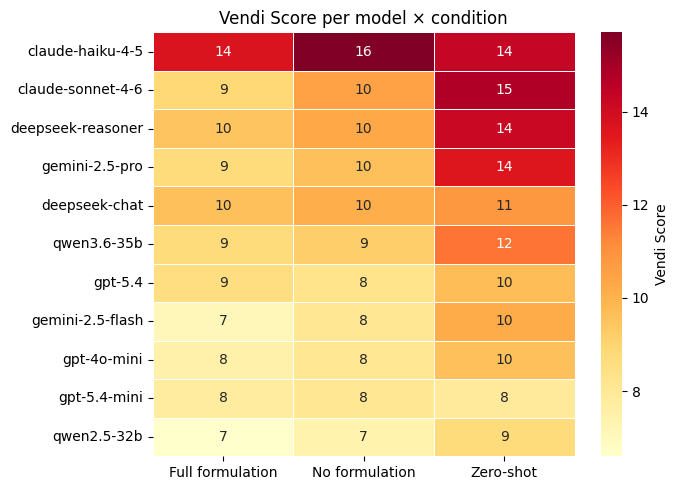

condition,Full formulation,No formulation,Zero-shot,mean
model,,,,
claude-haiku-4-5,13.7,15.7,14.3,14.566667
claude-sonnet-4-6,8.9,10.5,14.8,11.400000
deepseek-reasoner,9.5,10.3,14.2,11.333333
gemini-2.5-pro,8.7,9.6,13.6,10.633333
deepseek-chat,9.6,10.1,10.8,10.166667
qwen3.6-35b,8.7,9.2,11.6,9.833333
gpt-5.4,8.6,8.3,9.7,8.866667
gemini-2.5-flash,7.1,8.1,10.2,8.466667
gpt-4o-mini,7.5,8.1,9.6,8.400000


In [8]:
def vendi_score(embs):
    n = len(embs)
    K = embs @ embs.T
    K = K / n
    eigvals = np.linalg.eigvalsh(K)
    eigvals = eigvals[eigvals > 1e-10]
    eigvals /= eigvals.sum()
    return float(np.exp(-np.sum(eigvals * np.log(eigvals))))

rows = []
for model in sorted(df["model"].unique()):
    for cond, label in CONDITION_LABELS.items():
        idx  = df[(df["model"] == model) & (df["condition"] == cond)].index
        rows.append({"model": model, "condition": label,
                     "vendi_score": round(vendi_score(embeddings[idx]), 1)})

vendi_df = pd.DataFrame(rows)
pivot_v  = vendi_df.pivot(index="model", columns="condition", values="vendi_score")
pivot_v  = pivot_v[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
pivot_v["mean"] = pivot_v.mean(axis=1)
pivot_v  = pivot_v.sort_values("mean", ascending=False)
pivot_v.to_csv(ANALYSIS_DIR / "vendi_per_model_mpnet.csv")

fig, ax = plt.subplots(figsize=(7, 5))
data = pivot_v[[CONDITION_LABELS[c] for c in CONDITION_LABELS]]
sns.heatmap(data, ax=ax, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, cbar_kws={"label": "Vendi Score"})
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title("Vendi Score per model × condition", fontsize=12)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "vendi_heatmap_mpnet.pdf", bbox_inches="tight")
plt.show()
pivot_v

## 8. Emotion profile — j-hartmann/emotion-english-distilroberta-base
7 Ekman emotions per vignette (anger, disgust, fear, joy, neutral, sadness, surprise).  
Cached to `emotion_scores.parquet`. Delete cache to recompute (~10–15 min on CPU).

## 10. Token usage & iteration statistics per model × condition

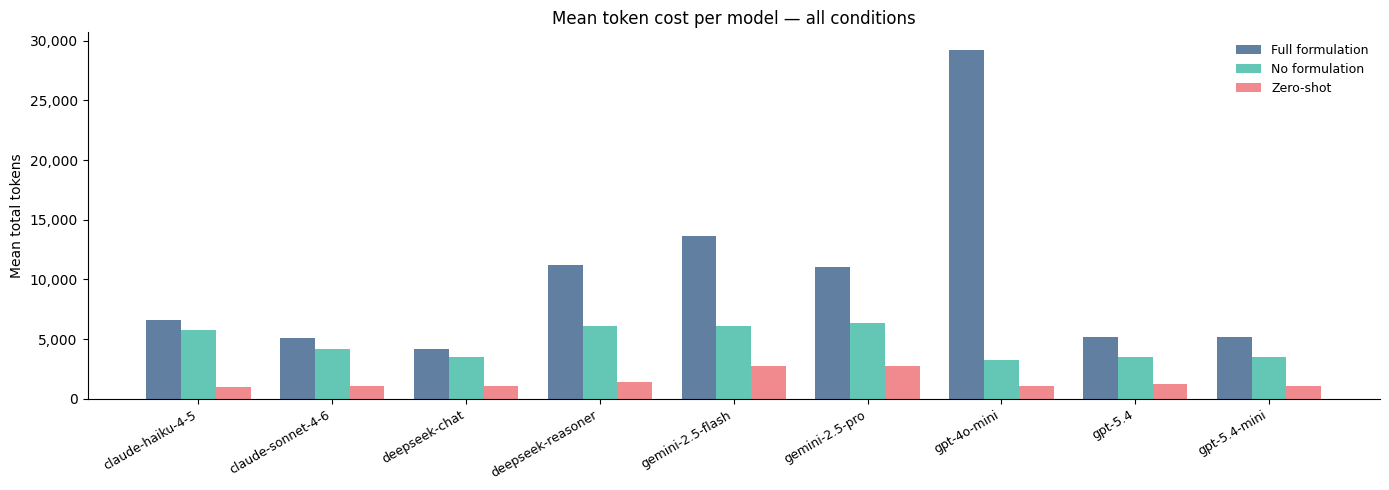

Mean total tokens per model × condition:
                   Full formulation  No formulation  Zero-shot
model                                                         
claude-haiku-4-5               6602            5768       1007
claude-sonnet-4-6              5062            4214       1062
deepseek-chat                  4159            3479       1050
deepseek-reasoner             11205            6108       1443
gemini-2.5-flash              13651            6075       2779
gemini-2.5-pro                11024            6379       2739
gpt-4o-mini                   29234            3238       1091
gpt-5.4                        5187            3539       1255
gpt-5.4-mini                   5144            3472       1111


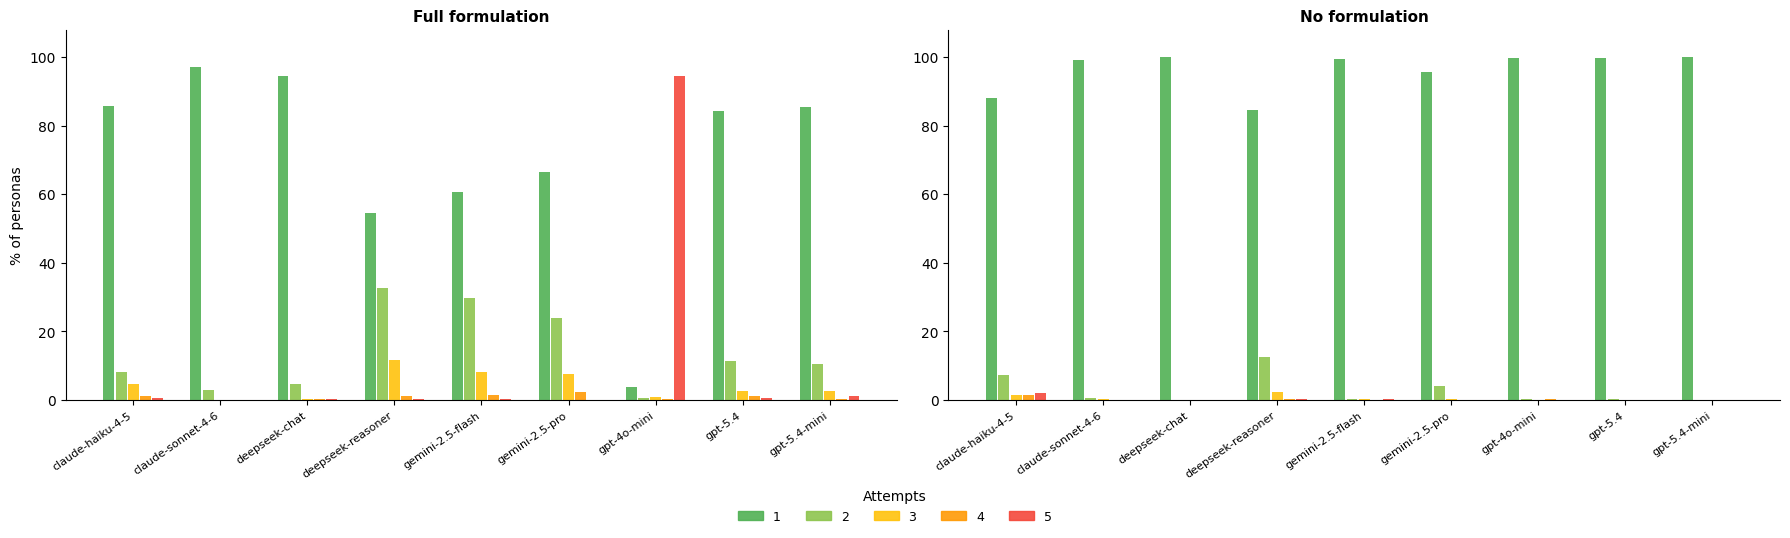

Saved: tokens_grouped_bar.pdf | iterations_grouped_bar.pdf


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

ANALYSIS_DIR = Path("../data/analysis")
CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {"full": "#456990", "no_formulation": "#49BEAA", "zero_shot": "#EF767A"}

_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gemini-2.5-pro", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
]

long = pd.read_csv(ANALYSIS_DIR / "personas_long.csv")
long = long[long["model"].isin(_EVAL_MODELS)]
long["condition_label"] = long["condition"].map(CONDITION_LABELS)

# ── 1. Combined grouped bar: mean tokens all 3 conditions per model ───────────
pivot_tokens = (
    long.groupby(["model", "condition"])["tokens_total"]
    .mean()
    .unstack("condition")
    [[c for c in CONDITION_LABELS if c in long["condition"].unique()]]
)
pivot_tokens.columns = [CONDITION_LABELS[c] for c in pivot_tokens.columns]
pivot_tokens = pivot_tokens.reindex([m for m in _EVAL_MODELS if m in pivot_tokens.index])

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(pivot_tokens))
w = 0.26
for i, (col, color) in enumerate(zip(pivot_tokens.columns, CONDITION_COLORS.values())):
    ax.bar(x + (i - 1) * w, pivot_tokens[col], width=w, label=col, color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(pivot_tokens.index, rotation=30, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylabel("Mean total tokens")
ax.set_title("Mean token cost per model — all conditions", fontsize=12)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "tokens_grouped_bar.pdf", bbox_inches="tight")
plt.show()

# ── 2. Mean tokens table — raw model names as in config ──────────────────────
pivot_raw = (
    long.groupby(["model", "condition"])["tokens_total"]
    .mean()
    .unstack("condition")
    [[c for c in CONDITION_LABELS if c in long["condition"].unique()]]
)
pivot_raw.columns = [CONDITION_LABELS[c] for c in pivot_raw.columns]
pivot_raw = pivot_raw.reindex([m for m in _EVAL_MODELS if m in pivot_raw.index])
print("Mean total tokens per model × condition:")
print(pivot_raw.round(0).astype("Int64").to_string(na_rep="—"))

# ── 3. Iteration distribution — grouped bar (full & no_formulation) ───────────
iter_df = long[long["condition"].isin(["full", "no_formulation"])].copy()
iter_df["n_attempts_capped"] = iter_df["n_attempts"].clip(upper=5).astype(int)

ATTEMPT_COLORS = {1: "#4CAF50", 2: "#8BC34A", 3: "#FFC107", 4: "#FF9800", 5: "#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, cond in zip(axes, ["full", "no_formulation"]):
    sub   = iter_df[iter_df["condition"] == cond]
    order = [m for m in _EVAL_MODELS if m in sub["model"].values]
    attempt_counts = (
        sub.groupby(["model", "n_attempts_capped"])
        .size().unstack(fill_value=0).reindex(order)
    )
    attempt_pct = attempt_counts.div(attempt_counts.sum(axis=1), axis=0) * 100
    attempt_cols = sorted(attempt_pct.columns)

    n_attempts = len(attempt_cols)
    x = np.arange(len(order))
    w = 0.7 / n_attempts

    for j, att in enumerate(attempt_cols):
        vals   = attempt_pct[att].values
        offset = (j - n_attempts / 2 + 0.5) * w
        ax.bar(x + offset, vals, width=w * 0.9,
               color=ATTEMPT_COLORS.get(att, "#9E9E9E"), alpha=0.88)

    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.set_title(CONDITION_LABELS[cond], fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("% of personas" if ax == axes[0] else "")
    ax.set_ylim(0, 108)
    ax.spines[["top", "right"]].set_visible(False)

# shared legend centred below both panels
attempt_cols_all = sorted(iter_df["n_attempts_capped"].unique())
handles = [mpatches.Patch(color=ATTEMPT_COLORS.get(a, "#9E9E9E"), alpha=0.88,
                          label=str(a))
           for a in attempt_cols_all]
fig.legend(handles=handles, title="Attempts", ncol=len(handles),
           loc="lower center", bbox_to_anchor=(0.5, -0.08), fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "iterations_grouped_bar.pdf", bbox_inches="tight")
plt.show()
print(f"Saved: tokens_grouped_bar.pdf | iterations_grouped_bar.pdf")

## 9. Persona identity preservation
For each persona, how similar are the vignettes generated by different models?  
**Within-persona** = same persona, different models. **Between-persona** = different personas, same condition.  
Higher within-persona similarity → models agree on how to portray that persona.

Loaded 16500 vignettes + embeddings


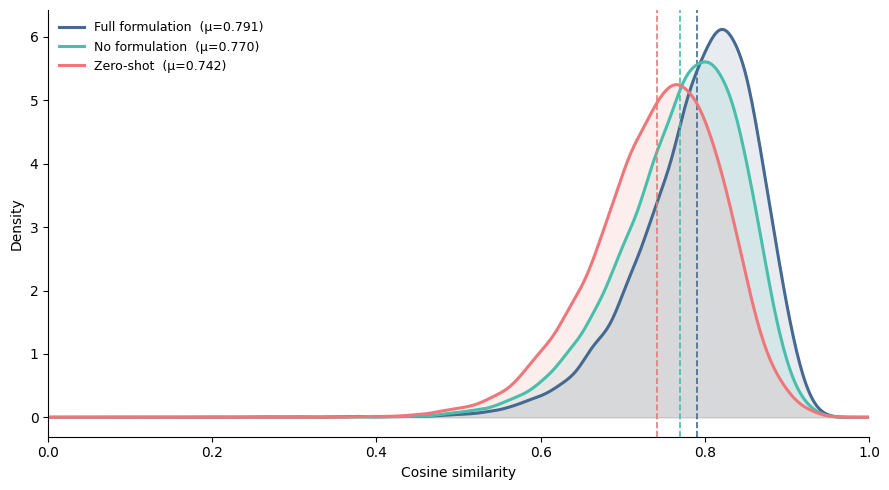


Paired t-tests on per-persona mean similarity (n = 500 personas)

Comparison                                     Δμ        t     df           p   Cohen d  sig
───────────────────────────────────────────────────────────────────────────────────────────────
Full formulation  vs  No formulation      +0.0205    16.36    499    1.75e-48   +0.7317  ***
Full formulation  vs  Zero-shot           +0.0486    31.53    499   7.85e-121   +1.4099  ***
No formulation  vs  Zero-shot             +0.0280    19.01    499    5.08e-61   +0.8502  ***

Effect size interpretation: |d| < 0.2 small, 0.2–0.5 medium, > 0.5 large


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import combinations
from pathlib import Path
from scipy.stats import gaussian_kde, ttest_rel
from scipy.stats import t as t_dist

ANALYSIS_DIR = Path("../data/analysis")
CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
CONDITION_COLORS = {"full": "#456990", "no_formulation": "#49BEAA", "zero_shot": "#EF767A"}

_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gemini-2.5-pro", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

# ── 0. Load from cache ────────────────────────────────────────────────────────
_df         = pd.read_parquet(ANALYSIS_DIR / "all_vignettes.parquet")
_embeddings = np.load(ANALYSIS_DIR / "embeddings_mpnet.npy")
_df = _df[_df["model"].isin(_EVAL_MODELS)].copy()
print(f"Loaded {len(_df)} vignettes + embeddings")

# ── 1. Collect within-persona cross-model similarities per condition ──────────
# cond_sims:       all raw pair similarities  (for KDE)
# persona_means:   mean similarity per persona (for hypothesis test)
cond_sims    = {c: [] for c in CONDITION_LABELS}
persona_means = {c: {} for c in CONDITION_LABELS}   # pid -> mean sim

for cond in CONDITION_LABELS:
    cond_df   = _df[_df["condition"] == cond].reset_index()
    cond_embs = _embeddings[cond_df["index"].values]
    cond_df   = cond_df.reset_index(drop=True)

    pid_model_idx = {}
    for i, row in cond_df.iterrows():
        pid_model_idx.setdefault(row["persona_id"], {})[row["model"]] = i

    for pid, model_map in pid_model_idx.items():
        models_present = list(model_map.keys())
        sims_for_pid = []
        for m1, m2 in combinations(models_present, 2):
            i1, i2 = model_map[m1], model_map[m2]
            s = float(cond_embs[i1] @ cond_embs[i2])
            cond_sims[cond].append(s)
            sims_for_pid.append(s)
        if sims_for_pid:
            persona_means[cond][pid] = np.mean(sims_for_pid)

# ── 2. KDE plot ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x_grid = np.linspace(0.0, 1.0, 500)

for cond, label in CONDITION_LABELS.items():
    sims = cond_sims[cond]
    col  = CONDITION_COLORS[cond]
    kde  = gaussian_kde(sims, bw_method=0.15)
    y    = kde(x_grid)
    mu   = np.mean(sims)
    ax.plot(x_grid, y, color=col, linewidth=2.2, label=f"{label}  (μ={mu:.3f})")
    ax.fill_between(x_grid, y, alpha=0.12, color=col)
    ax.axvline(mu, color=col, linewidth=1.2, linestyle="--")

ax.set_xlim(0.0, 1.0)
ax.set_xlabel("Cosine similarity", fontsize=10)
ax.set_ylabel("Density", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "persona_identity_distributions.pdf", bbox_inches="tight")
plt.show()

# ── 3. Paired t-tests on per-persona means (500 independent observations) ────
# Using paired t-test: same 500 personas appear in all 3 conditions
conds = list(CONDITION_LABELS.keys())
pairs = list(combinations(conds, 2))

def cohens_d(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

print("\nPaired t-tests on per-persona mean similarity (n = 500 personas)\n")
print(f"{'Comparison':<40}  {'Δμ':>7}  {'t':>7}  {'df':>5}  {'p':>10}  {'Cohen d':>8}  {'sig'}")
print("─" * 95)

for c1, c2 in pairs:
    pids  = sorted(set(persona_means[c1]) & set(persona_means[c2]))
    a     = np.array([persona_means[c1][p] for p in pids])
    b     = np.array([persona_means[c2][p] for p in pids])
    t_stat, p_val = ttest_rel(a, b)
    d     = cohens_d(a, b)
    delta = a.mean() - b.mean()
    sig   = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    label = f"{CONDITION_LABELS[c1]}  vs  {CONDITION_LABELS[c2]}"
    print(f"{label:<40}  {delta:>+7.4f}  {t_stat:>7.2f}  {len(pids)-1:>5}  {p_val:>10.2e}  {d:>+8.4f}  {sig}")

print("\nEffect size interpretation: |d| < 0.2 small, 0.2–0.5 medium, > 0.5 large")

Loaded cached emotion scores: 14981 rows
                anger  disgust   fear    joy  neutral  sadness  surprise
condition                                                               
full            0.035    0.099  0.802  0.001    0.025    0.029     0.009
no_formulation  0.031    0.121  0.774  0.001    0.033    0.029     0.012
zero_shot       0.034    0.158  0.615  0.002    0.129    0.045     0.017


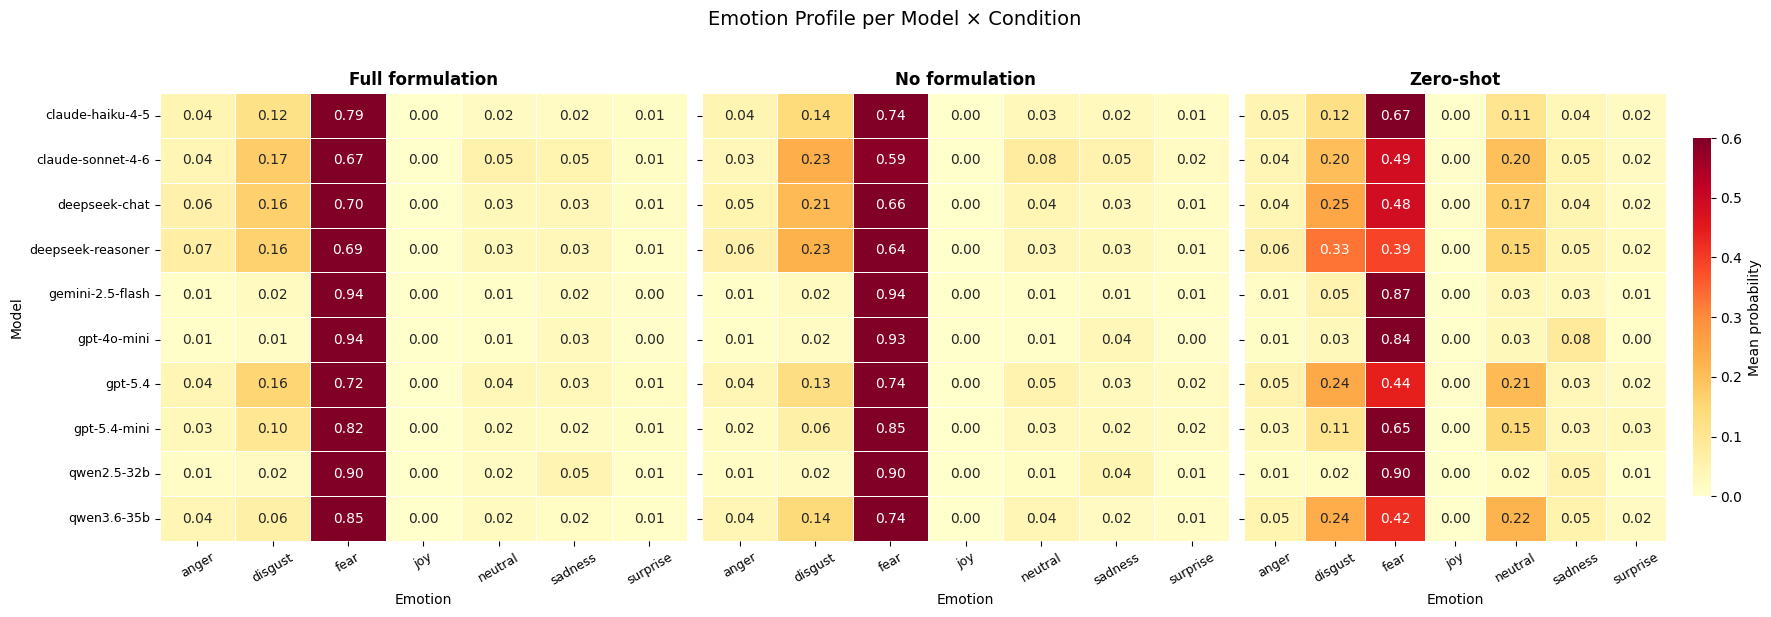

Saved -> ..\data\analysis/emotion_heatmap.pdf


In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import pipeline

ANALYSIS_DIR  = Path("../data/analysis")
EMO_CACHE     = ANALYSIS_DIR / "emotion_scores.parquet"

CONDITION_LABELS = {
    "full":           "Full formulation",
    "no_formulation": "No formulation",
    "zero_shot":      "Zero-shot",
}
EMOTIONS = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]

# ── 1. Compute or load ────────────────────────────────────────────────────────
if EMO_CACHE.exists():
    emo_df = pd.read_parquet(EMO_CACHE)
    print(f"Loaded cached emotion scores: {len(emo_df)} rows")
else:
    vig_cache = ANALYSIS_DIR / "all_vignettes.parquet"
    df_v = pd.read_parquet(vig_cache)
    print(f"Scoring {len(df_v)} vignettes...")

    clf = pipeline(
        "text-classification",
        model="j-hartmann/emotion-english-distilroberta-base",
        top_k=None,
        truncation=True,
        max_length=512,
        device=-1,       # CPU; set device=0 for GPU
    )

    records = []
    batch_size = 32
    texts = df_v["vignette"].tolist()
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        results = clf(batch)
        for j, res in enumerate(results):
            row = {r["label"]: r["score"] for r in res}
            row["_idx"] = i + j
            records.append(row)
        if i % 1000 == 0:
            print(f"  {i}/{len(texts)}")

    scores = pd.DataFrame(records).set_index("_idx").reindex(columns=EMOTIONS).fillna(0)
    emo_df = pd.concat([df_v[["persona_id", "model", "condition"]].reset_index(drop=True),
                        scores.reset_index(drop=True)], axis=1)
    emo_df.to_parquet(EMO_CACHE, index=False)
    print(f"Saved -> {EMO_CACHE}")

print(emo_df.groupby("condition")[EMOTIONS].mean().round(3))

# ── 2. Heatmap: mean emotion per model × condition ────────────────────────────
_EVAL_MODELS = [
    "claude-haiku-4-5", "claude-sonnet-4-6", "deepseek-chat", "deepseek-reasoner",
    "gemini-2.5-flash", "gpt-4o-mini", "gpt-5.4", "gpt-5.4-mini",
    "qwen2.5-32b", "qwen3.6-35b",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (cond, label) in zip(axes, CONDITION_LABELS.items()):
    sub = emo_df[(emo_df["condition"] == cond) & (emo_df["model"].isin(_EVAL_MODELS))]
    pivot = sub.groupby("model")[EMOTIONS].mean().reindex(_EVAL_MODELS)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=0.6, linewidths=0.4,
                cbar=(ax == axes[-1]),
                cbar_kws={"label": "Mean probability", "shrink": 0.8})
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Emotion"); ax.set_ylabel("" if ax != axes[0] else "Model")
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Emotion Profile per Model × Condition", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "emotion_heatmap.pdf", bbox_inches="tight")
plt.show()
print(f"Saved -> {ANALYSIS_DIR}/emotion_heatmap.pdf")

